# Data Visualization
This notebook describes how the finalized visualization was generated to address the question of interest: 

**Which US counties emit the most CO₂ from non-residential fuel use per square meter of building floor area?**

In [24]:
#%pip install geopandas 

In [25]:
#%pip install duckdb
#%pip install pandas 
import duckdb as duckdb 
import pandas as pd 
import matplotlib.pyplot as plt
import geopandas as gpd

In [26]:
# Establish connection 
# Established connection to database
conn = duckdb.connect("/Users/vedikashirtekar/MEDS/EDS-213/eds-213-labs/my-db.duckdb")

In [27]:
'''sources_emissions_top_10 = conn.sql("""SELECT s.source_name, s.iso3_country, SUM(e.emissions_quantity), s.capacity,
    ROUND(SUM(e.emissions_quantity) / (s.capacity), 6) AS co2_per_m2
    FROM sources s
    JOIN emission_records e ON s.source_id = e.source_id
    WHERE e.sector LIKE 'buildings'
    GROUP BY s.source_name, s.iso3_country, s.capacity
    ORDER BY co2_per_m2 DESC;""").df()'''

'sources_emissions_top_10 = conn.sql("""SELECT s.source_name, s.iso3_country, SUM(e.emissions_quantity), s.capacity,\n    ROUND(SUM(e.emissions_quantity) / (s.capacity), 6) AS co2_per_m2\n    FROM sources s\n    JOIN emission_records e ON s.source_id = e.source_id\n    WHERE e.sector LIKE \'buildings\'\n    GROUP BY s.source_name, s.iso3_country, s.capacity\n    ORDER BY co2_per_m2 DESC;""").df()'

In [28]:
sources_emissions_top_10 = conn.sql("""SELECT 
    s.source_name, 
    ROUND(
        SUM(e.emissions_quantity) / s.capacity 
           / COUNT(DISTINCT EXTRACT(YEAR FROM e.start_time)), 3) AS    
           Co2_per_m2_per_year 
         FROM sources s
         JOIN emission_records e ON s.source_id = e.source_id
         WHERE e.sector = 'buildings' AND s.capacity_units = 'm^2'
         GROUP BY s.source_name, s.capacity
          ORDER BY co2_per_m2_per_year DESC;""").df()

In [34]:
sources_emissions_top_10

,source_name,Co2_per_m2_per_year
0,Menifee County,NaN
1,Kenedy County,NaN
2,Edwards County,NaN
3,Owsley County,NaN
4,Arthur County,NaN
...,...,...
3403,Culberson County,0.001
3404,Irion County,0.001
3405,Upton County,0.001
3406,Kent County,0.000


In [35]:
# We can now drop the NANs... 
sources_emissions_clean_top_10 = sources_emissions_top_10.dropna()

# sources_emissions_clean.to_csv('data/new_tables/sources_emissions_clean.csv', index=False)

In [36]:
sources_emissions_clean_top_10 = sources_emissions_clean_top_10.head(10)


# Dependencies pip freeze  > requirements.txt
# read in the sources_emissions_clean data as geopandas 


In [39]:
#sources_top_10 = sources_emissions_clean
# Export
#sources_top_10.to_csv('data/new_tables/sources_top10.csv', index=False)
#sources_top_10
sources_emissions_clean_top_10.head(10)

,source_name,Co2_per_m2_per_year
5,Wade Hampton Census Area,0.781
6,Nome Census Area,0.760
7,Kodiak Island Borough,0.550
8,Northwest Arctic Borough,0.469
9,Matanuska-Susitna Borough,0.465
10,Kenai Peninsula Borough,0.355
11,Aleutians East Borough,0.289
12,Haines Borough,0.283
13,Skagway-Yakutat-Angoon Census Area,0.273
14,Bethel Census Area,0.254


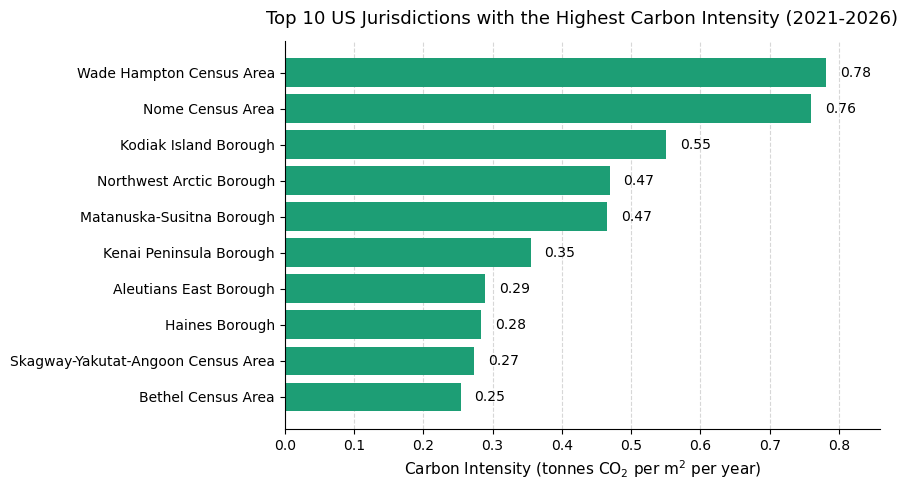

In [40]:

bars = fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    sources_emissions_clean_top_10['source_name'], 
    sources_emissions_clean_top_10['Co2_per_m2_per_year'], 
    color='#1D9E75', 
    edgecolor='none'
)

ax.invert_yaxis()
ax.set_xlabel("Carbon Intensity (tonnes CO$_2$ per m$^2$ per year)", fontsize=11)
ax.set_title("Top 10 US Jurisdictions with the Highest Carbon Intensity (2021-2026)", fontsize=13, pad=12)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(0, sources_emissions_clean_top_10["Co2_per_m2_per_year"].max() * 1.1)  # a little breathing room on the right
ax.xaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

for bar, val in zip(bars, sources_emissions_clean_top_10["Co2_per_m2_per_year"]):
    ax.text(val + 0.02, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('co2_per_m2.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
conn.close() #To ensure lock isn't there